## Black-hole binary formation channels with gaussian mixtures.

1) Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?

2) We'll use `sklearn.mixture.GaussianMixture`. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

*Note*. We'll do a more formal introduction to scikit-learn in one of the next lectures. Today's exercise is meant to be a formative example on how you might find yourself dealing with a library you've never seen before. This happens *all the time* in research...

3) Complete the fit 10 times with $N=1,...,10$ Gaussians. 

Note: `sklearn` by default will use the so-called [Expectation-Maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), which is one of the many great things in data science we don't have time to study in this class.

4) For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

5) Plot the preferred solution on top of the input data. You should get a very nice fit!


In [11]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

In [12]:
data = np.load('formationchannels.npy')

Let's have a quick look at the data:

Text(0.5, 0, 'BH mass')

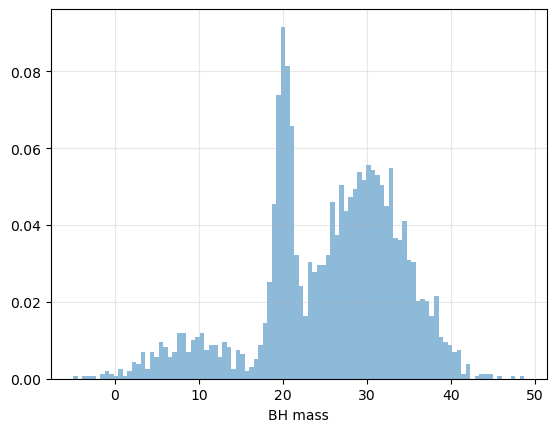

In [13]:
plt.hist(data, bins=100, density=True, alpha=0.5)
plt.grid(alpha=0.3)
plt.xlabel('BH mass')

It seems there are three modes!

Let's try to fit our data with different GMMs and look at the AIC values to see which model is the most favored:

Text(0, 0.5, 'AIC')

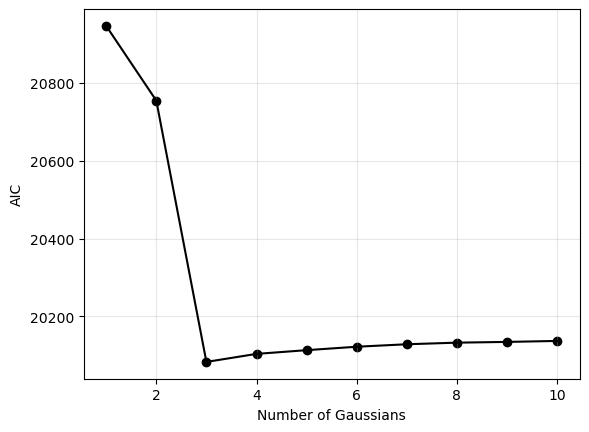

In [14]:
N = 10
AICs = []

for i in range(N):
    model = GaussianMixture(i+1)
    model.fit(data)
    AIC = model.aic(data)
    AICs.append(AIC)

n = np.linspace(1,10,10)
plt.plot(n, AICs, '-k')
plt.scatter(n, AICs, c='k')
plt.grid(alpha=0.3)
plt.xlabel('Number of Gaussians')
plt.ylabel('AIC')

In [15]:
n_sort = np.argsort(AICs)
n_best = n[n_sort[0]]
print(f'Best model has {n_best} Gaussians')

Best model has 3.0 Gaussians


The best model is a mixture of three gaussians!

Let's overplot it to the data to see if it is a good fit:

In [21]:
best_model = GaussianMixture(int(n_best))
best_model.fit(data)
x = np.linspace(-5, 50, 10000)
new_x = x[:, np.newaxis]
y = np.exp(best_model.score_samples(X = new_x))

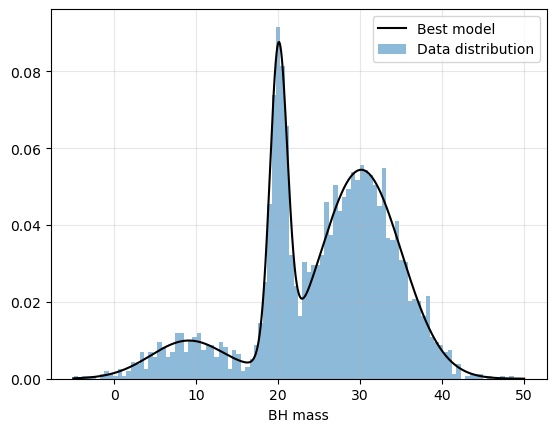

In [22]:
plt.plot(x, y, '-k', label='Best model')
plt.hist(data, bins=100, density=True, alpha=0.5, label='Data distribution')
plt.grid(alpha=0.3)
plt.xlabel('BH mass')
plt.legend()

It looks pretty nice!

#### [Optional tasks, not examinable] Class labels or "responsibilities"

6) [**Optional**] Understand (i.e. plot) which Gaussian mode corresponds to which part of the input dataset. 

*Hint:* Useful methods here are `score_samples` and `predict_proba`.

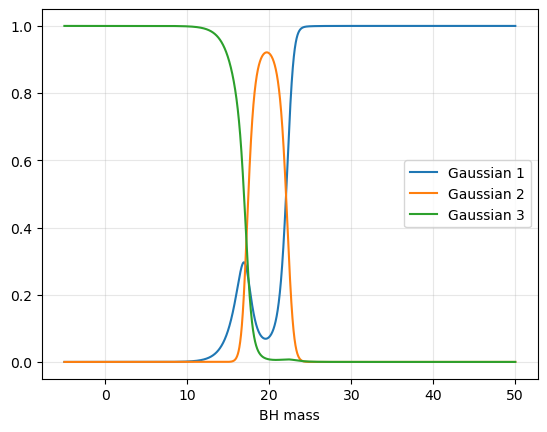

In [25]:
probs = best_model.predict_proba(new_x)
for i in range(int(n_best)):
    plt.plot(x, probs[:,i], label = f'Gaussian {i+1}')
plt.xlabel('BH mass')
plt.grid(alpha=0.3)
plt.legend()

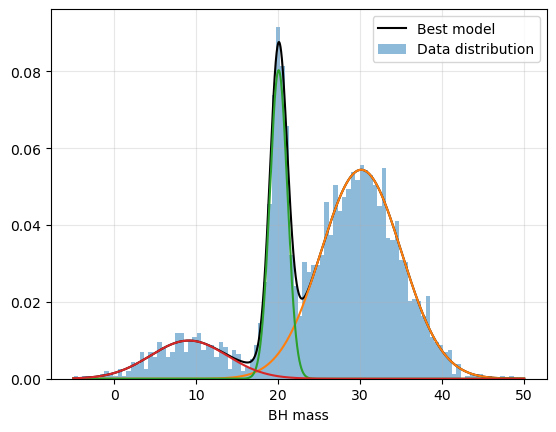

In [26]:
means = best_model.means_
covs = best_model.covariances_
weights = best_model.weights_
sigmas = []
for cov in covs:
    sigma = np.array(np.sqrt(np.diag(cov)))
    sigmas.append(sigma)

plt.plot(x, y, '-k', label='Best model')
plt.hist(data, bins=100, density=True, alpha=0.5, label='Data distribution')
for mean, sigma, weight in zip(means, sigmas, weights):
    plt.plot(x, weight*norm.pdf(x, mean, sigma))
plt.grid(alpha=0.3)
plt.xlabel('BH mass')
plt.legend()